# Fig 3/4 — CellxGene atlas covariance transfer

Reproduces the CellxGene-**atlas** covariance-transfer panels for the main figures: can a
covariance/Sigma estimated from an external CellxGene *atlas* (matched cell types) drive
CIPHER's linear-response predictions on held-out perturbation datasets, versus the
dataset's own precomputed Sigma and negative controls?

Two authoritative pipelines:

1. **Marson T-cell atlas transfer** — Marson perturb-seq responses vs. stratified CellxGene
   atlas covariances for **CD4 T**, **CD8 T**, Treg, PBMC non-T, and tissue non-T groups,
   plus a target-shuffled negative control.
2. **RPE atlas transfer (streamed)** — Replogle/Kaden RPE1 perturb-seq responses vs.
   within/cross-dataset Sigma, a CellxGene **RPE** atlas source, and a far-from-RPE atlas
   negative control (covariance streamed in chunks).

Stateless helpers live in `notebooks/src/suppl_atlas.py`; each pipeline keeps its own
config constants and config-coupled / plotting functions inline (they differ between the
two snapshots), which is what makes each cell reproduce 1:1.

**Data gap:** requires the CellxGene atlas objects (CD4_T / CD8_T / RPE) via
`cellxgene_census`, plus the precomputed Marson Sigma folders — none are staged locally, so
these cells are cleaned faithfully but not yet runnable. Base perturb-seq h5ads live under
`$CIPHER_DATA_DIR`; supplemental inputs under `$CIPHER_DATA_DIR/suppl`.


In [1]:
import os, sys
# route tqdm progress bars to text (stderr -> log) instead of un-renderable ipywidgets
import importlib as _il
try:
    _std_tqdm = _il.import_module('tqdm.std').tqdm
    for _m in ('tqdm', 'tqdm.auto', 'tqdm.notebook', 'tqdm.autonotebook'):
        try: _il.import_module(_m).tqdm = _std_tqdm
        except Exception: pass
except Exception:
    pass
# make notebooks/ importable so `from src.suppl_atlas import *` works from notebooks/suppl/
sys.path.insert(0, os.path.dirname(os.getcwd()) if os.path.basename(os.getcwd()) == "suppl" else os.getcwd())

from src.suppl_atlas import *

DATA_DIR = os.environ["CIPHER_DATA_DIR"]          # base perturb-seq h5ads (no fallback)
SUPPL = os.path.join(DATA_DIR, "suppl")            # supplemental inputs (precomputed Sigma, etc.)
SUPPL_OUT = os.environ.get("SUPPL_OUT", "resources/repro/fig3")
OUTDIR = SUPPL_OUT                                 # base output dir; each pipeline nests under it
os.makedirs(SUPPL_OUT, exist_ok=True)
from src.logutil import route_logs  # verbose logs -> .log, plots stay in-cell
route_logs("fig3_atlas")
print("DATA_DIR:", DATA_DIR)
print("SUPPL:   ", SUPPL)
print("SUPPL_OUT:", SUPPL_OUT)

[logs] verbose output -> ../../resources/repro/fig3/logs/fig3_atlas.log
DATA_DIR: $CIPHER_DATA_DIR
SUPPL:    $SUPPL
SUPPL_OUT: $SUPPL_OUT


In [2]:
import src.run_fig3_atlas as R
import src.suppl_atlas as C
_cfg = {k: v for k, v in globals().items() if k.isupper() or k in ("DATA_DIR", "SUPPL", "OUTDIR")}
R.__dict__.update(_cfg); C.__dict__.update(_cfg)

## 1. Marson T-cell CellxGene atlas transfer (CD4 T / CD8 T)

The `marson_cellxgene_robust_atlas_transfer` pipeline. Marson perturb-seq responses are
scored against their own precomputed Sigma and against within-stratum-averaged CellxGene
atlas covariances for CD4 T, CD8 T, Treg, PBMC non-T, and tissue non-T groups, plus a
target-shuffled negative control. Config-coupled and plotting helpers are kept inline.

,dataset,label,condition,folder,n_genes,n_perts_total,n_perts_matched,stats_path,sigma_path
0,Marson2025_D1_Rest_filtered__mean_ge_1p0,Marson2025_D1_Rest,Rest,Marson2025_D1_Rest_filtered__mean_ge_1p0,3172,967,967,perturbation_stats.h5,Sigma_full_ridge.npy
1,Marson2025_D1_Stim48hr_filtered__mean_ge_1p0,Marson2025_D1_Stim48hr,Stim48hr,Marson2025_D1_Stim48hr_filtered__mean_ge_1p0,4741,969,969,perturbation_stats.h5,Sigma_full_ridge.npy
2,Marson2025_D1_Stim8hr_filtered__mean_ge_1p0,Marson2025_D1_Stim8hr,Stim8hr,Marson2025_D1_Stim8hr_filtered__mean_ge_1p0,4394,971,971,perturbation_stats.h5,Sigma_full_ridge.npy
3,Marson2025_D2_Stim48hr_filtered__mean_ge_1p0,Marson2025_D2_Stim48hr,Stim48hr,Marson2025_D2_Stim48hr_filtered__mean_ge_1p0,3575,979,979,perturbation_stats.h5,Sigma_full_ridge.npy
4,Marson2025_D2_Stim8hr_filtered__mean_ge_1p0,Marson2025_D2_Stim8hr,Stim8hr,Marson2025_D2_Stim8hr_filtered__mean_ge_1p0,4463,979,979,perturbation_stats.h5,Sigma_full_ridge.npy
5,Marson2025_D3_Rest_filtered__mean_ge_1p0,Marson2025_D3_Rest,Rest,Marson2025_D3_Rest_filtered__mean_ge_1p0,3495,962,962,perturbation_stats.h5,Sigma_full_ridge.npy
6,Marson2025_D3_Stim48hr_filtered__mean_ge_1p0,Marson2025_D3_Stim48hr,Stim48hr,Marson2025_D3_Stim48hr_filtered__mean_ge_1p0,4343,965,965,perturbation_stats.h5,Sigma_full_ridge.npy
7,Marson2025_D3_Stim8hr_filtered__mean_ge_1p0,Marson2025_D3_Stim8hr,Stim8hr,Marson2025_D3_Stim8hr_filtered__mean_ge_1p0,4788,960,960,perturbation_stats.h5,Sigma_full_ridge.npy
8,Marson2025_D4_Rest_filtered__mean_ge_1p0,Marson2025_D4_Rest,Rest,Marson2025_D4_Rest_filtered__mean_ge_1p0,2960,972,972,perturbation_stats.h5,Sigma_full_ridge.npy
9,Marson2025_D4_Stim48hr_filtered__mean_ge_1p0,Marson2025_D4_Stim48hr,Stim48hr,Marson2025_D4_Stim48hr_filtered__mean_ge_1p0,4645,969,969,perturbation_stats.h5,Sigma_full_ridge.npy


,source_dataset,source_label,source_type,composite_group,dataset_id,resample_id,dataset_title,cell_type_top,cell_types_seen,tissue_top,tissue_general_top,tissues_seen,n_cells_available,n_cells_sampled,n_donors,sample_obs_path
0,CELLxGENE__PBMC_CD4_T_cells__1b9d8702-5af8-414...,PBMC CD4 T 1.0: blood,CELLxGENE PBMC CD4 T cells,PBMC CD4 T cells,1b9d8702-5af8-4142-85ed-020eb06ec4f6,0,Global,"naive thymus-derived CD4-positive, alpha-beta ...",CD4-positive helper T cell; naive thymus-deriv...,blood,blood,blood,10975,10000,6,$SUPPL_OUT/marson_cellxgene_robust_atlas_trans...
1,CELLxGENE__PBMC_CD4_T_cells__1b9d8702-5af8-414...,PBMC CD4 T 1.1: blood,CELLxGENE PBMC CD4 T cells,PBMC CD4 T cells,1b9d8702-5af8-4142-85ed-020eb06ec4f6,1,Global,"naive thymus-derived CD4-positive, alpha-beta ...",CD4-positive helper T cell; naive thymus-deriv...,blood,blood,blood,10975,10000,6,$SUPPL_OUT/marson_cellxgene_robust_atlas_trans...
2,CELLxGENE__PBMC_CD4_T_cells__1b9d8702-5af8-414...,PBMC CD4 T 1.2: blood,CELLxGENE PBMC CD4 T cells,PBMC CD4 T cells,1b9d8702-5af8-4142-85ed-020eb06ec4f6,2,Global,"naive thymus-derived CD4-positive, alpha-beta ...",CD4-positive helper T cell; naive thymus-deriv...,blood,blood,blood,10975,10000,6,$SUPPL_OUT/marson_cellxgene_robust_atlas_trans...
3,CELLxGENE__PBMC_CD4_T_cells__242c6e7f-9016-404...,PBMC CD4 T 2.0: blood,CELLxGENE PBMC CD4 T cells,PBMC CD4 T cells,242c6e7f-9016-4048-af70-d631f5eea188,0,"Circulating Immune cells -- CV19 infection, va...","CD4-positive, alpha-beta T cell","CD4-positive, alpha-beta T cell",blood,blood,blood,49555,10000,9,$SUPPL_OUT/marson_cellxgene_robust_atlas_trans...
4,CELLxGENE__PBMC_CD4_T_cells__242c6e7f-9016-404...,PBMC CD4 T 2.1: blood,CELLxGENE PBMC CD4 T cells,PBMC CD4 T cells,242c6e7f-9016-4048-af70-d631f5eea188,1,"Circulating Immune cells -- CV19 infection, va...","CD4-positive, alpha-beta T cell","CD4-positive, alpha-beta T cell",blood,blood,blood,49555,10000,9,$SUPPL_OUT/marson_cellxgene_robust_atlas_trans...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
166,CELLxGENE__Tissue_non-T_cells__f0f0d7c4-3bec-4...,Tissue non-T 7.1: skin of body,CELLxGENE Tissue non-T cells,Tissue non-T cells,f0f0d7c4-3bec-428e-9539-c99d36548d96,1,Human healthy adult skin scRNA-seq data,macrophage,macrophage,dermis,skin of body,skin epidermis; dermis,12117,10000,5,$SUPPL_OUT/marson_cellxgene_robust_atlas_trans...
167,CELLxGENE__Tissue_non-T_cells__f0f0d7c4-3bec-4...,Tissue non-T 7.2: skin of body,CELLxGENE Tissue non-T cells,Tissue non-T cells,f0f0d7c4-3bec-428e-9539-c99d36548d96,2,Human healthy adult skin scRNA-seq data,macrophage,macrophage,dermis,skin of body,skin epidermis; dermis,12117,10000,5,$SUPPL_OUT/marson_cellxgene_robust_atlas_trans...
168,CELLxGENE__Tissue_non-T_cells__74cff64f-9da9-4...,Tissue non-T 8.0: placenta,CELLxGENE Tissue non-T cells,Tissue non-T cells,74cff64f-9da9-4b2a-9b3b-8a04a1598040,0,All donors all cell states (in vivo),stromal cell,epithelial cell; macrophage; stromal cell,decidua,placenta,decidua; placenta,89906,10000,28,$SUPPL_OUT/marson_cellxgene_robust_atlas_trans...
169,CELLxGENE__Tissue_non-T_cells__74cff64f-9da9-4...,Tissue non-T 8.1: placenta,CELLxGENE Tissue non-T cells,Tissue non-T cells,74cff64f-9da9-4b2a-9b3b-8a04a1598040,1,All donors all cell states (in vivo),stromal cell,epithelial cell; macrophage; stromal cell,decidua,placenta,decidua; placenta,89906,10000,28,$SUPPL_OUT/marson_cellxgene_robust_atlas_trans...


,source_dataset,source_label,source_type,composite_group,covariance_variant,covariance_mode,n_cells,n_valid_strata,median_gene_mean,median_gene_detection,median_target_mean,median_target_detection,n_targets_passing_expression,cache_path
0,CELLxGENE__PBMC_CD4_T_cells__1b9d8702-5af8-414...,PBMC CD4 T 1.1: blood,CELLxGENE PBMC CD4 T cells,PBMC CD4 T cells,depth_resid,within_strata,10000,7,0.11410,0.10285,0.07485,0.06885,2654,$SUPPL_OUT/marson_cellxgene_robust_atlas_trans...
1,CELLxGENE__PBMC_CD4_T_cells__1b9d8702-5af8-414...,PBMC CD4 T 1.2: blood,CELLxGENE PBMC CD4 T cells,PBMC CD4 T cells,depth_resid,within_strata,10000,7,0.11440,0.10280,0.07495,0.06880,2657,$SUPPL_OUT/marson_cellxgene_robust_atlas_trans...
2,CELLxGENE__PBMC_CD4_T_cells__1b9d8702-5af8-414...,PBMC CD4 T 1.0: blood,CELLxGENE PBMC CD4 T cells,PBMC CD4 T cells,depth_resid,within_strata,10000,7,0.11415,0.10270,0.07475,0.06900,2655,$SUPPL_OUT/marson_cellxgene_robust_atlas_trans...
3,CELLxGENE__PBMC_CD4_T_cells__242c6e7f-9016-404...,PBMC CD4 T 2.0: blood,CELLxGENE PBMC CD4 T cells,PBMC CD4 T cells,depth_resid,within_strata,10000,9,0.06000,0.05600,0.03845,0.03615,2459,$SUPPL_OUT/marson_cellxgene_robust_atlas_trans...
4,CELLxGENE__PBMC_CD4_T_cells__242c6e7f-9016-404...,PBMC CD4 T 2.1: blood,CELLxGENE PBMC CD4 T cells,PBMC CD4 T cells,depth_resid,within_strata,10000,9,0.06060,0.05660,0.03880,0.03685,2461,$SUPPL_OUT/marson_cellxgene_robust_atlas_trans...
5,CELLxGENE__PBMC_CD4_T_cells__1b350d0a-4535-487...,PBMC CD4 T 3.0: blood,CELLxGENE PBMC CD4 T cells,PBMC CD4 T cells,depth_resid,within_strata,10000,16,0.12180,0.10620,0.07700,0.07005,2684,$SUPPL_OUT/marson_cellxgene_robust_atlas_trans...
6,CELLxGENE__PBMC_CD4_T_cells__1b350d0a-4535-487...,PBMC CD4 T 3.1: blood,CELLxGENE PBMC CD4 T cells,PBMC CD4 T cells,depth_resid,within_strata,10000,15,0.12175,0.10625,0.07710,0.06975,2686,$SUPPL_OUT/marson_cellxgene_robust_atlas_trans...
7,CELLxGENE__PBMC_CD4_T_cells__242c6e7f-9016-404...,PBMC CD4 T 2.2: blood,CELLxGENE PBMC CD4 T cells,PBMC CD4 T cells,depth_resid,within_strata,10000,9,0.06070,0.05615,0.03885,0.03675,2467,$SUPPL_OUT/marson_cellxgene_robust_atlas_trans...
8,CELLxGENE__PBMC_CD4_T_cells__1b350d0a-4535-487...,PBMC CD4 T 3.2: blood,CELLxGENE PBMC CD4 T cells,PBMC CD4 T cells,depth_resid,within_strata,10000,15,0.12325,0.10705,0.07730,0.06990,2685,$SUPPL_OUT/marson_cellxgene_robust_atlas_trans...
9,CELLxGENE__PBMC_CD4_T_cells__01ad3cd7-3929-465...,PBMC CD4 T 4.0: blood,CELLxGENE PBMC CD4 T cells,PBMC CD4 T cells,depth_resid,within_strata,10000,8,0.05290,0.05050,0.03535,0.03395,2442,$SUPPL_OUT/marson_cellxgene_robust_atlas_trans...


,composite_group,n_pairs,mean_pair_pearson_lto,mean_pair_r2_lto,total_eval_perts
0,Marson within dataset,11,0.404023,0.254892,10665
1,Marson within condition,30,0.376441,0.234105,13588
2,Marson cross condition,80,0.373794,0.227464,43581
3,PBMC CD4 T cells,264,0.120523,0.025599,188412
4,PBMC CD8 T cells,264,0.134812,0.028712,204056
5,PBMC Treg cells,99,0.122783,0.029515,73247
6,PBMC generic T cells,33,0.142010,0.032146,27306
7,Tissue CD4 T cells,264,0.136109,0.029560,194590
8,Tissue CD8 T cells,231,0.126144,0.025222,178618
9,Tissue generic T cells,198,0.113972,0.022543,146888


,composite_group,n,mean,median,std,sem,min,max
0,Marson within dataset,11,0.404023,0.386427,0.074087,0.022338,0.332750,0.546881
1,Marson within condition,30,0.376441,0.351138,0.067643,0.012350,0.307722,0.537938
2,Marson cross condition,80,0.373794,0.358433,0.056078,0.006270,0.277572,0.491872
3,PBMC CD4 T cells,264,0.120523,0.123647,0.048855,0.003007,0.024266,0.238068
4,PBMC CD8 T cells,264,0.134812,0.129064,0.028472,0.001752,0.086249,0.210518
5,PBMC Treg cells,99,0.122783,0.141821,0.070372,0.007073,0.028712,0.256570
6,PBMC generic T cells,33,0.142010,0.129934,0.027766,0.004833,0.112432,0.197309
7,Tissue CD4 T cells,264,0.136109,0.133907,0.034172,0.002103,0.080353,0.250524
8,Tissue CD8 T cells,231,0.126144,0.121375,0.022974,0.001512,0.081127,0.182833
9,Tissue generic T cells,198,0.113972,0.102202,0.040040,0.002845,0.070391,0.259217


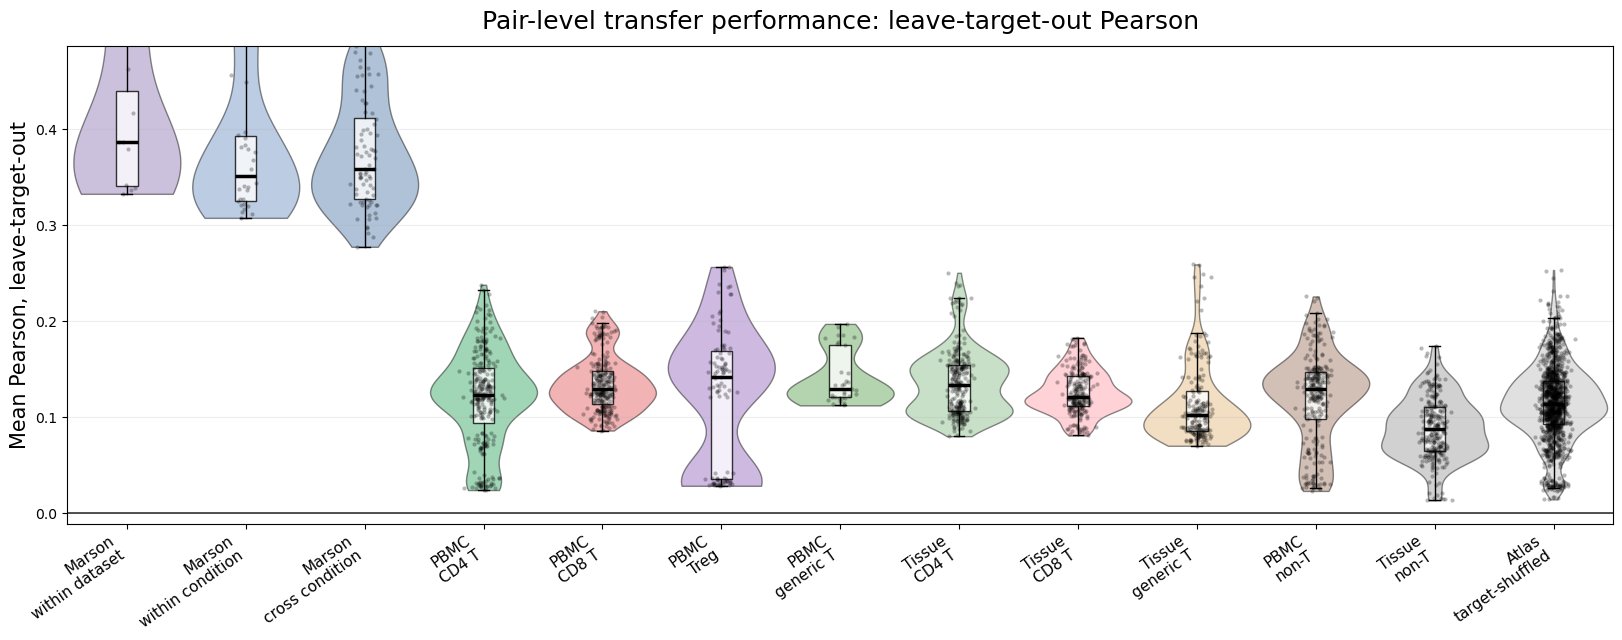

,composite_group,n,mean,median,std,sem,min,max
0,Marson within dataset,11,0.254892,0.237257,0.070054,0.021122,0.182172,0.397344
1,Marson within condition,30,0.234105,0.209821,0.062031,0.011325,0.169571,0.391038
2,Marson cross condition,80,0.227464,0.215693,0.047472,0.005307,0.155425,0.335529
3,PBMC CD4 T cells,264,0.025599,0.024190,0.016438,0.001012,0.000997,0.077798
4,PBMC CD8 T cells,264,0.028712,0.025474,0.011552,0.000711,0.012311,0.064464
5,PBMC Treg cells,99,0.029515,0.029861,0.024639,0.002476,0.001441,0.091767
6,PBMC generic T cells,33,0.032146,0.027001,0.011972,0.002084,0.020741,0.057201
7,Tissue CD4 T cells,264,0.029560,0.027343,0.014600,0.000899,0.010981,0.089486
8,Tissue CD8 T cells,231,0.025222,0.023116,0.008810,0.000580,0.010216,0.050470
9,Tissue generic T cells,198,0.022543,0.016511,0.017527,0.001246,0.007766,0.100040


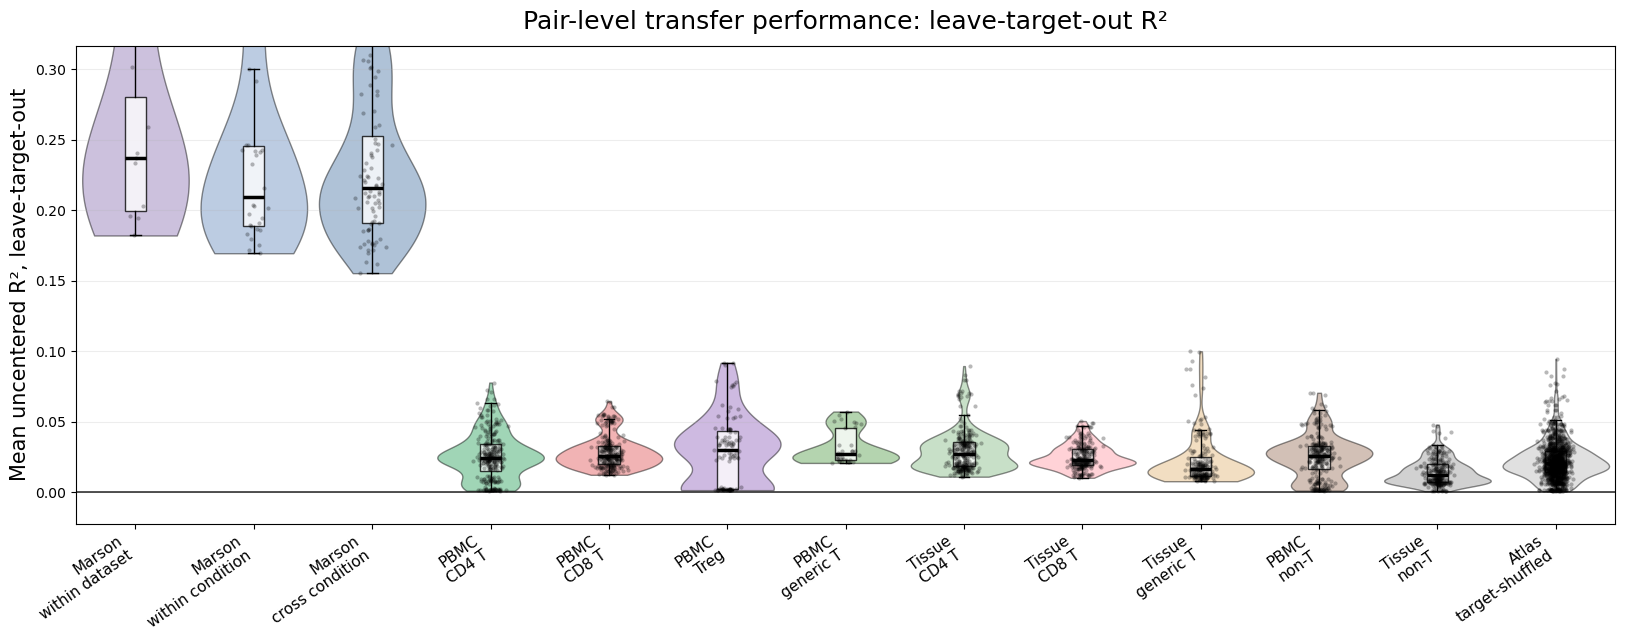

,composite_group,n,mean,median,std,sem,min,max
0,Marson within dataset,11,0.386856,0.371058,0.070914,0.021381,0.316484,0.522499
1,Marson within condition,30,0.368031,0.345277,0.065426,0.011945,0.297352,0.528654
2,Marson cross condition,80,0.363370,0.351318,0.055009,0.006150,0.270113,0.480630
3,PBMC CD4 T cells,264,0.116583,0.120925,0.046988,0.002892,0.026195,0.229648
4,PBMC CD8 T cells,264,0.130010,0.125163,0.027072,0.001666,0.082903,0.206639
5,PBMC Treg cells,99,0.118220,0.131083,0.066373,0.006671,0.030407,0.251188
6,PBMC generic T cells,33,0.139373,0.127072,0.026837,0.004672,0.110056,0.194304
7,Tissue CD4 T cells,264,0.132137,0.127798,0.034197,0.002105,0.075063,0.249373
8,Tissue CD8 T cells,231,0.122776,0.118826,0.021849,0.001438,0.080701,0.178596
9,Tissue generic T cells,198,0.110701,0.100670,0.037449,0.002661,0.069389,0.250115


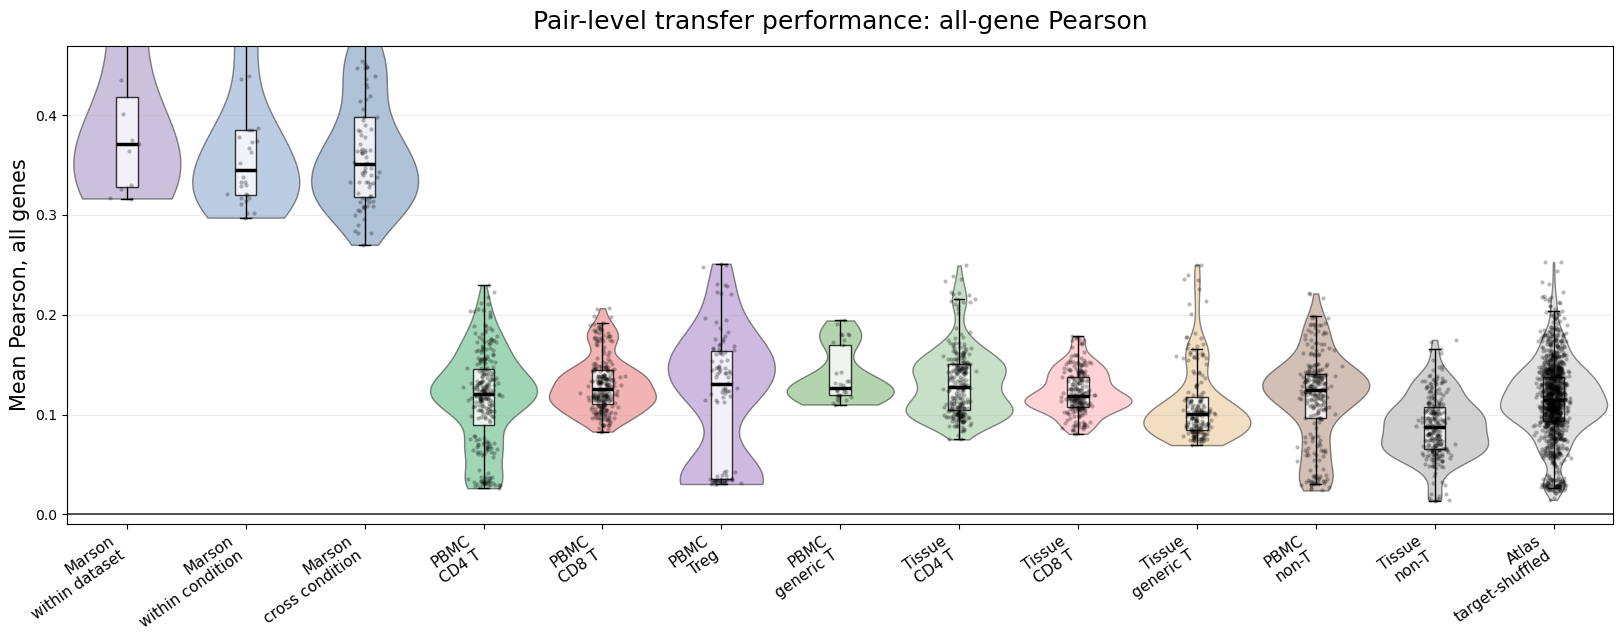

,composite_group,n,mean,median,std,sem,min,max
0,Marson within dataset,11,0.243866,0.227594,0.066967,0.020191,0.173167,0.379052
1,Marson within condition,30,0.228506,0.205639,0.059972,0.010949,0.164467,0.383092
2,Marson cross condition,80,0.220788,0.208177,0.046388,0.005186,0.151249,0.326991
3,PBMC CD4 T cells,264,0.024231,0.023311,0.015298,0.000942,0.001296,0.073283
4,PBMC CD8 T cells,264,0.026889,0.024517,0.010621,0.000654,0.011445,0.062480
5,PBMC Treg cells,99,0.027476,0.025613,0.022814,0.002293,0.001569,0.088274
6,PBMC generic T cells,33,0.031142,0.026068,0.011355,0.001977,0.019829,0.055762
7,Tissue CD4 T cells,264,0.028166,0.025034,0.014381,0.000885,0.009195,0.088504
8,Tissue CD8 T cells,231,0.024048,0.022072,0.008288,0.000545,0.010080,0.048379
9,Tissue generic T cells,198,0.021347,0.015939,0.015951,0.001134,0.007544,0.093296


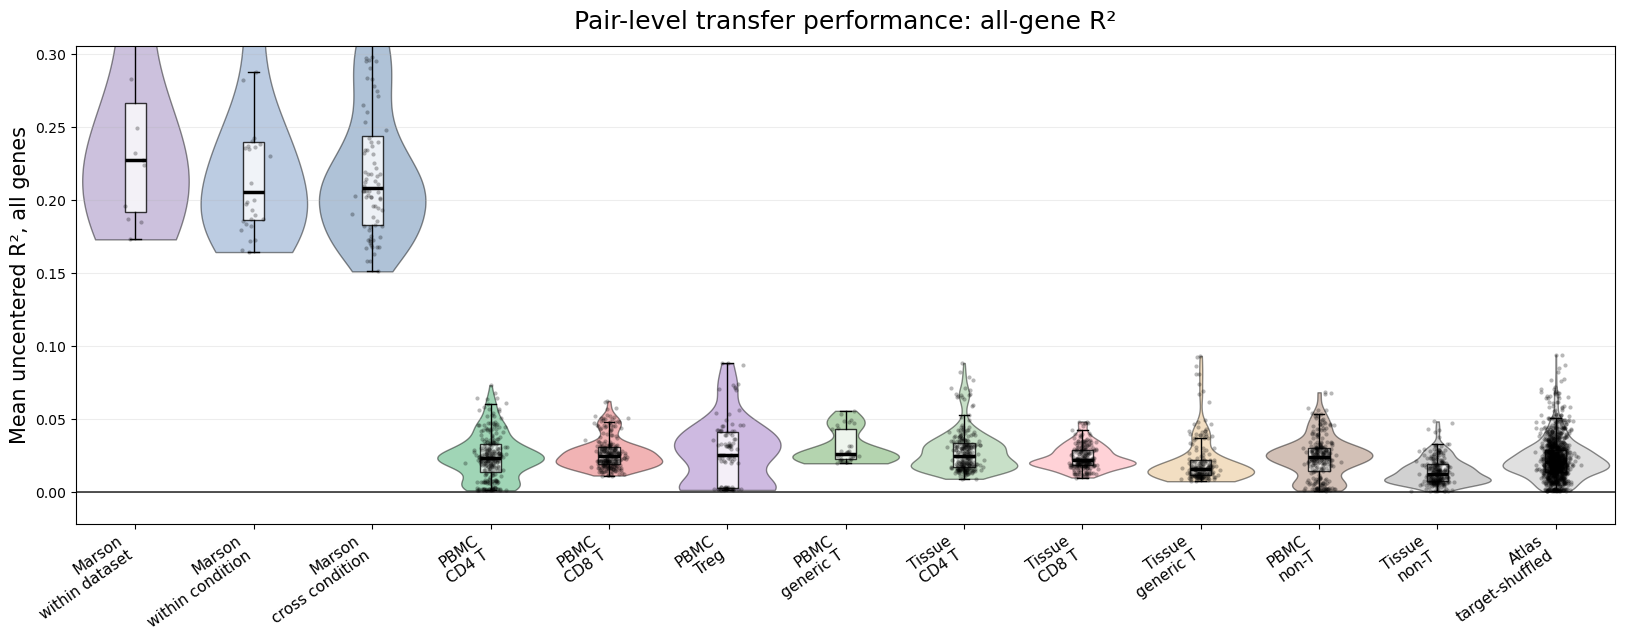

,composite_group,n,mean,median,std,sem,min,max
0,Marson within dataset,10222,0.403878,0.392630,0.253395,0.002506,-0.150185,0.979259
1,Marson within condition,13311,0.373528,0.361069,0.243251,0.002108,-0.189866,0.973507
2,Marson cross condition,42339,0.374309,0.368359,0.233429,0.001134,-0.197396,0.929072
3,PBMC CD4 T cells,188412,0.122864,0.087223,0.114261,0.000263,-0.016807,0.772912
4,PBMC CD8 T cells,204056,0.135278,0.106611,0.111110,0.000246,-0.016434,0.710010
5,PBMC Treg cells,73247,0.123745,0.072899,0.128765,0.000476,-0.014909,0.737927
6,PBMC generic T cells,27306,0.142062,0.111470,0.116993,0.000708,-0.021763,0.664503
7,Tissue CD4 T cells,194590,0.137485,0.107236,0.114989,0.000261,-0.021842,0.775610
8,Tissue CD8 T cells,178618,0.125493,0.098331,0.104542,0.000247,-0.017946,0.709402
9,Tissue generic T cells,146888,0.113686,0.084093,0.104372,0.000272,-0.012471,0.775839


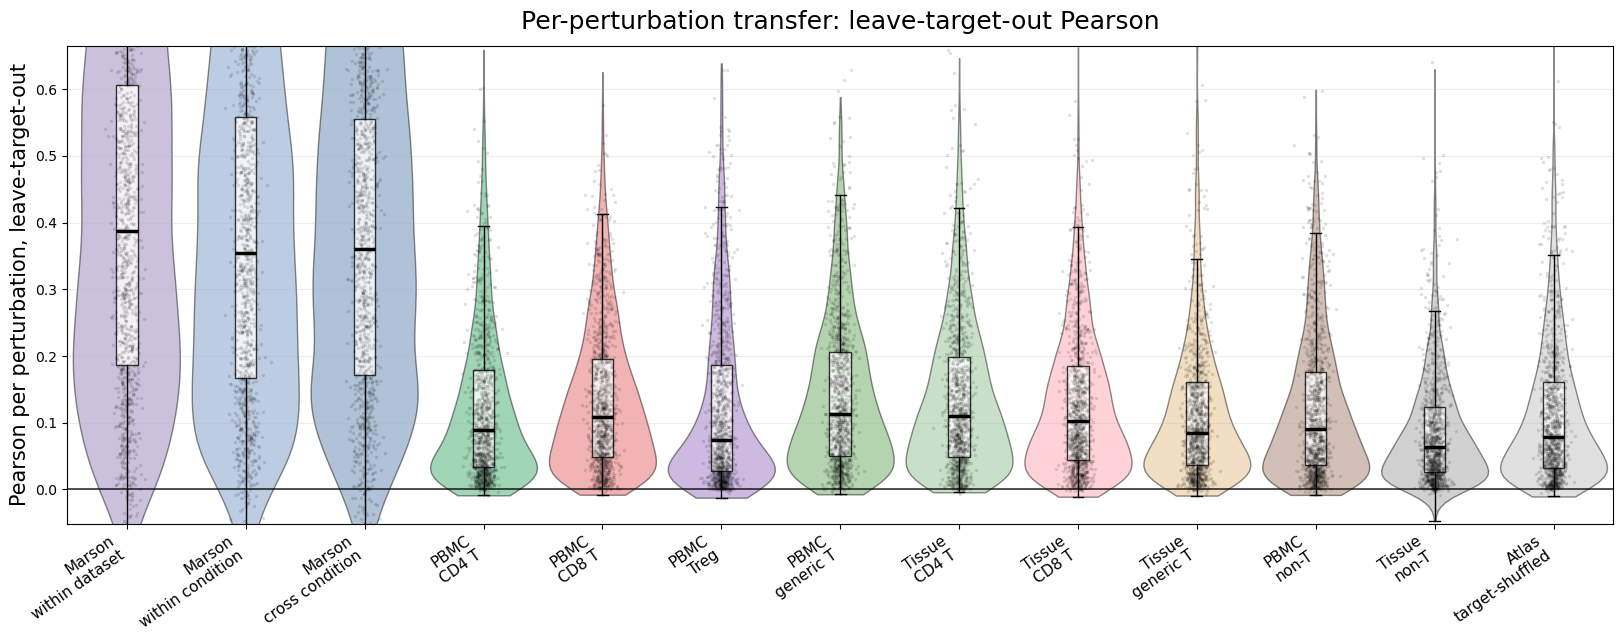

,composite_group,n,mean,median,std,sem,min,max
0,Marson within dataset,10222,0.254775,0.185713,0.237343,0.002348,5.906558e-09,0.965790
1,Marson within condition,13311,0.231504,0.163016,0.221333,0.001918,1.947334e-09,0.958758
2,Marson cross condition,42339,0.227550,0.169567,0.206043,0.001001,5.870643e-10,0.888319
3,PBMC CD4 T cells,188412,0.026451,0.007292,0.045261,0.000104,8.726353e-14,0.543271
4,PBMC CD8 T cells,204056,0.028916,0.010877,0.043525,0.000096,4.772849e-13,0.467975
5,PBMC Treg cells,73247,0.029997,0.005114,0.054694,0.000202,7.328582e-12,0.499328
6,PBMC generic T cells,27306,0.032168,0.011971,0.048369,0.000293,3.627543e-12,0.400629
7,Tissue CD4 T cells,194590,0.030114,0.010907,0.047475,0.000108,1.771028e-12,0.546475
8,Tissue CD8 T cells,178618,0.024999,0.009142,0.039338,0.000093,5.116352e-12,0.459598
9,Tissue generic T cells,146888,0.022615,0.006781,0.043142,0.000113,1.456613e-13,0.566337


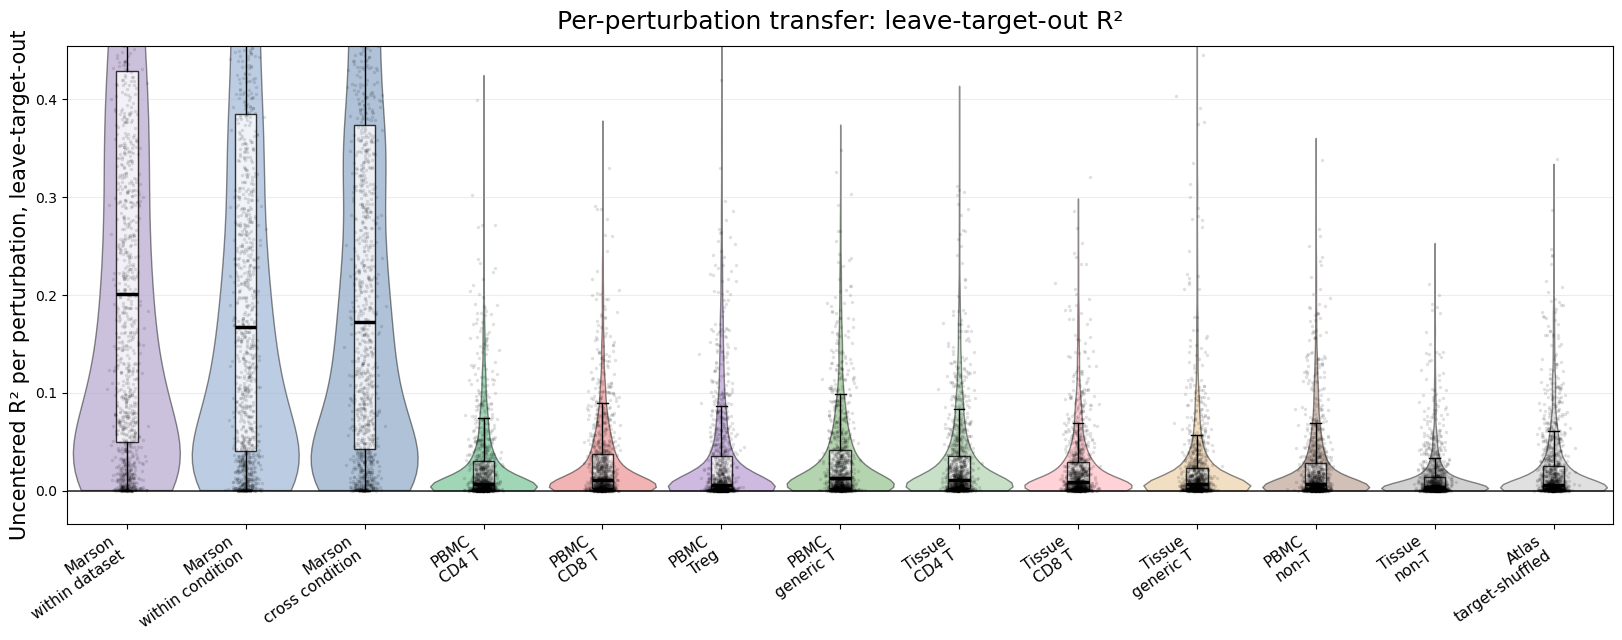

In [3]:
R.marson_cellxgene_robust_atlas_transfer()

## 2. RPE CellxGene atlas transfer (streamed)

The `rpe_first3_plus_far_from_rpe_atlas_streamed` pipeline. RPE1 perturb-seq responses
are scored against within/cross-dataset Sigma, a CellxGene RPE atlas source, and a
far-from-RPE atlas negative control; the atlas covariance is streamed in chunks. Config
constants and config-coupled / plotting helpers are kept inline.

,dataset,label,path,pert_key,n_genes,n_perts,n_unique_targets,n_control_total,n_control_sigma
0,ReplogleWeissman2022_rpe1,Replogle RPE1,$CIPHER_DATA_DIR/ReplogleWeissman2022_rpe1.h5ad,perturbation,8749,659,659,11485,10000
1,kaden25_rpe1_ctrl_10k_min100_greedy_4gb,Kaden RPE1,$CIPHER_DATA_DIR/kaden25_rpe1_ctrl_10k_min100_...,perturbation,12661,1044,1044,10000,10000


,source_dataset,source_label,source_type,composite_group,dataset_id,dataset_title,cell_type_top,tissue_top,tissue_general_top,tissues_seen,tissue_generals_seen,n_cells_available,n_cells_sampled,sample_obs_path
0,CELLxGENE_RPE_5ed90bc0-12f3-4354-b314-0ce0dbb9...,RPE atlas1: retinal pigment epithelial cell | eye,CELLxGENE RPE atlas raw covariance,CELLxGENE RPE atlas cells,5ed90bc0-12f3-4354-b314-0ce0dbb96458,scRNA-seq of human of the human retinal pigmen...,retinal pigment epithelial cell,chorioretinal region,eye,chorioretinal region; eyeball of camera-type e...,eye,10289,5000,$SUPPL_OUT/rpe_first3_plus_far_from_rpe_atlas_...
1,CELLxGENE_POOLED_FAR_FROM_RPE_ATLAS,Pooled CELLxGENE far-from-RPE atlas,CELLxGENE pooled far-from-RPE raw covariance,CELLxGENE far-from-RPE atlas cells,pooled_far_from_rpe_atlas,pooled selected far-from-RPE atlas datasets,mixed far-from-RPE cells,mixed far-from-RPE tissues,mixed far-from-RPE tissues,decidua; placenta; blood; subcutaneous adipose...,placenta; blood; adipose tissue; kidney; colon...,40000,40000,$SUPPL_OUT/rpe_first3_plus_far_from_rpe_atlas_...


,composite_group,n_pairs,mean_pair_pearson,mean_pair_r2,total_eval_perts
0,RPE Pert-seq within dataset,2,0.507258,0.358130,1703
1,RPE Pert-seq cross dataset,2,0.490262,0.307379,74
2,CELLxGENE RPE atlas cells,2,0.358995,0.178519,1692
3,CELLxGENE far-from-RPE atlas cells,2,0.441311,0.262547,1692


,composite_group,n,mean,median,std,sem,min,max
0,RPE Pert-seq within dataset,1703,0.513590,0.563621,0.315672,0.007649,-0.023683,0.981405
1,RPE Pert-seq cross dataset,74,0.490262,0.543985,0.235791,0.027410,-0.007770,0.815319
2,CELLxGENE RPE atlas cells,1692,0.355759,0.370894,0.199096,0.004840,-0.034342,0.828491
3,CELLxGENE far-from-RPE atlas cells,1692,0.450389,0.479159,0.245111,0.005959,-0.029448,0.882363


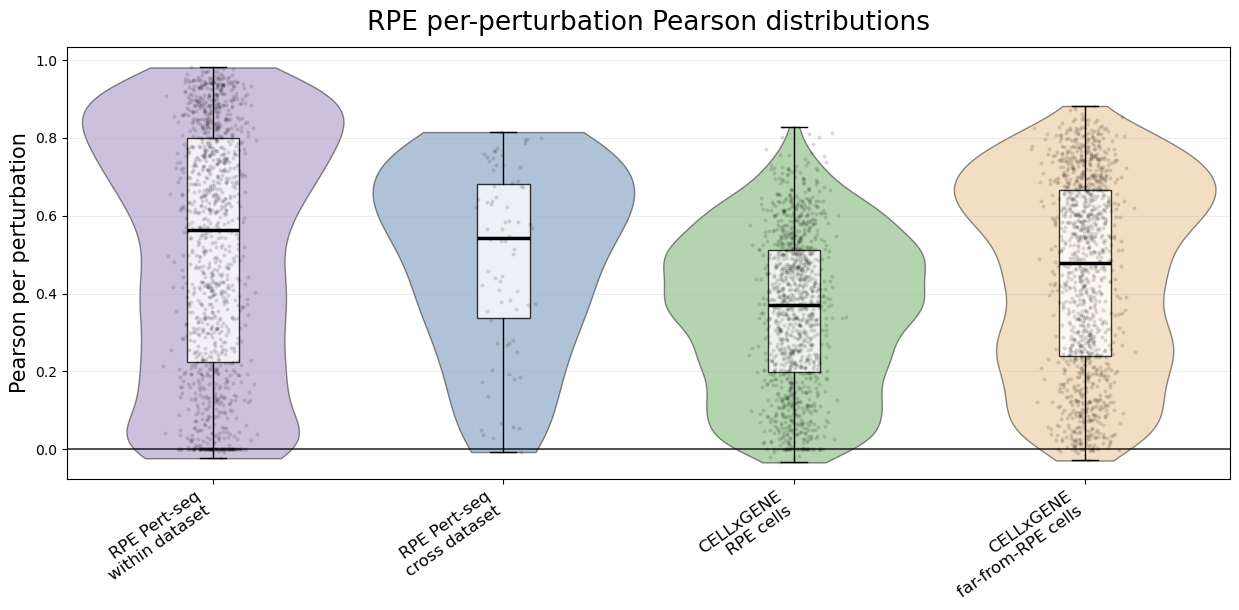

,composite_group,n,mean,median,std,sem,min,max
0,RPE Pert-seq within dataset,1703,0.369093,0.328274,0.310911,0.007534,0.000000,0.965080
1,RPE Pert-seq cross dataset,74,0.307379,0.312188,0.215882,0.025096,0.000066,0.683759
2,CELLxGENE RPE atlas cells,1692,0.175323,0.151288,0.149055,0.003624,0.000000,0.691457
3,CELLxGENE far-from-RPE atlas cells,1692,0.271282,0.241911,0.217901,0.005297,0.000000,0.787851


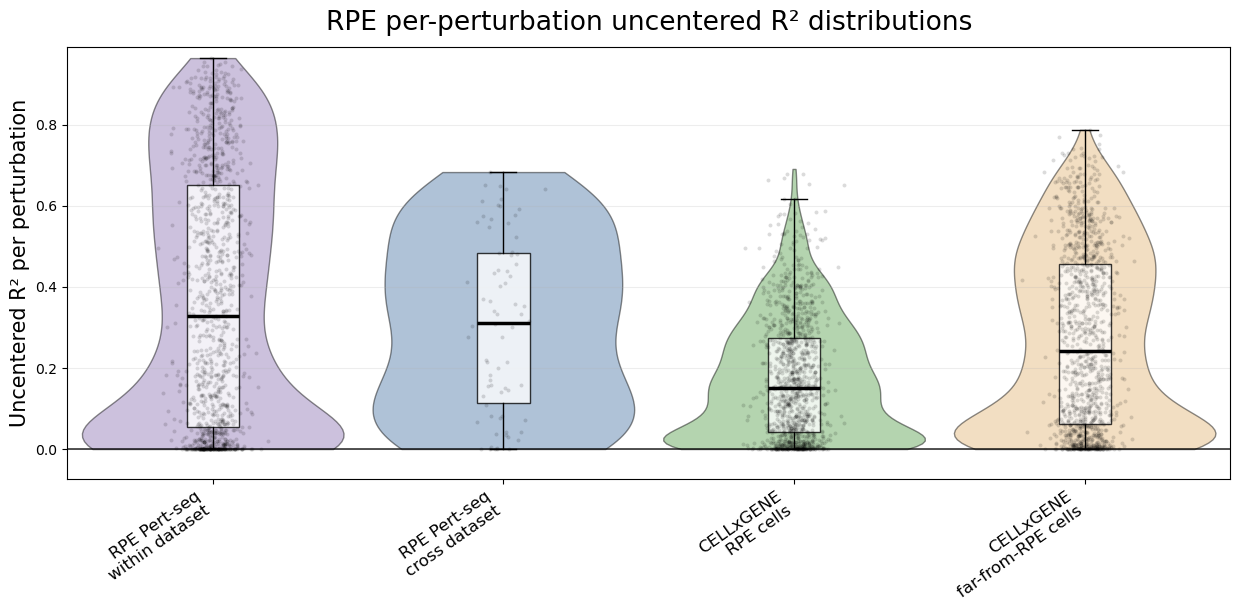

In [4]:
R.rpe_first3_plus_far_from_rpe_atlas_streamed()